# All Interesting Variables Compare in Different Regions in Salish Sea

## Region 

Print the index of interesting regions inside Salish sea. Indexes copied from https://github.com/SalishSeaCast/analysis-junqi/blob/main/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00Mar2023_flux/00Mar2023_SST.ipynb

Locations Added to the Map section.

In [ ]:
# Stations
# ============================================================
# stations = {
#     'Pam Rocks': {
#         'y': 502,
#         'x': 341,
#         'lat': 49.487434,
#         'lon': -123.30153,
#     },

#     'Sand Heads': {
#         'y': 428,
#         'x': 293,
#         'lat': 49.107586,
#         'lon': -123.30203,
#     },
# }

### Map

The codes below were modified from https://github.com/SalishSeaCast/Suchyetal_MHWpaper/blob/main/MHW_Code_For_Publishing/Figure1_MapModelDomain_MHW.ipynb

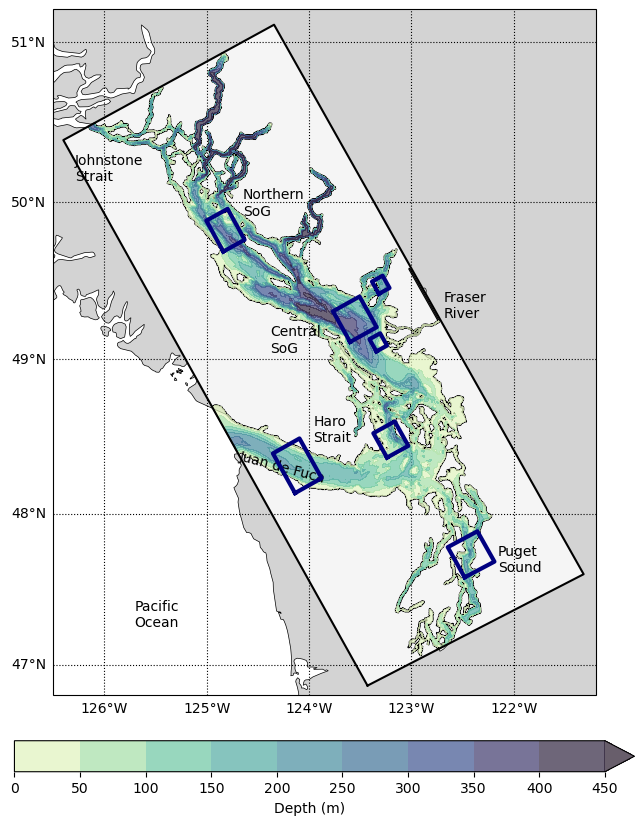

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean
import cartopy.feature as cfeature
from cartopy import crs, feature
from cartopy.mpl.gridliner import (
    LONGITUDE_FORMATTER,
    LATITUDE_FORMATTER,
)

# ============================================================
# 1. Load model grid / mask
# ============================================================

grid = xr.open_dataset(
    "/ocean/ksuchy/MOAD/NEMO-forcing/grid/bathymetry_202108.nc",
    mask_and_scale=False,
)

mask = xr.open_dataset(
    "/ocean/ksuchy/MOAD/NEMO-forcing/grid/mesh_mask202108.nc"
)

lon = grid.nav_lon.values
lat = grid.nav_lat.values
bathy = grid.Bathymetry.values

# Surface ocean mask:
# 1 = water, 0 = land
tmask = mask.tmask[0, 0, :, :].values


# ============================================================
# 2. Helper: draw a box defined in NEMO grid-index space
# ============================================================

def plot_grid_box(ax, j0, j1, i0, i1,
                  color="navy", linewidth=3):
    """
    Draw a rectangular region whose bounds are given by
    NEMO grid indices.

    j0, j1 : y-index limits
    i0, i1 : x-index limits
    """

    corners = [
        (j0, i0),
        (j0, i1),
        (j1, i1),
        (j1, i0),
        (j0, i0),
    ]

    box_lon = [lon[j, i] for j, i in corners]
    box_lat = [lat[j, i] for j, i in corners]

    ax.plot(
        box_lon,
        box_lat,
        color=color,
        linewidth=linewidth,
        transform=crs.PlateCarree(),
        zorder=5,
    )


# ============================================================
# 3. Make map
# ============================================================

xlim = [-126.5, -121.2]
ylim = [46.8, 51.2]

fig, ax = plt.subplots(
    figsize=(8, 10),
    subplot_kw={
        "projection": crs.Mercator(
            central_longitude=np.mean(xlim)
        )
    },
)

ax.set_extent(
    [xlim[0], xlim[1], ylim[0], ylim[1]],
    crs=crs.PlateCarree(),
)


# ============================================================
# 4. Geographic coastline / land
# ============================================================

# ax.add_feature(
#     feature.GSHHSFeature(
#         scale="full",
#         edgecolor="black",
#         facecolor="lightgrey",
#     ),
#     zorder=0,
# )

ax.add_feature(
    cfeature.LAND.with_scale("10m"),
    facecolor="lightgrey",
    edgecolor="black",
    linewidth=0.5,
    zorder=0,
)


# ============================================================
# 5. Model domain land/water boundary
# ============================================================

# Similar to the original notebook:
# overlay the model mask to show the actual NEMO model domain.

ax.contourf(
    lon,
    lat,
    tmask,
    levels=[-0.01, 0.01],
    colors=["whitesmoke"],
    transform=crs.PlateCarree(),
    zorder=1,
)

ax.contour(
    lon,
    lat,
    tmask,
    levels=[0.01],
    colors="black",
    linewidths=0.8,
    transform=crs.PlateCarree(),
    zorder=2,
)


# ============================================================
# 6. Draw outer model-domain boundary
# ============================================================

domain_corners = [
    (0, 0),
    (0, -1),
    (-1, -1),
    (-1, 0),
    (0, 0),
]

domain_lon = [lon[j, i] for j, i in domain_corners]
domain_lat = [lat[j, i] for j, i in domain_corners]

ax.plot(
    domain_lon,
    domain_lat,
    "k-",
    linewidth=1.5,
    transform=crs.PlateCarree(),
    zorder=4,
)


# ============================================================
# 7. Bathymetry
# ============================================================

# Mask land cells
bathy_masked = np.ma.masked_where(
    tmask == 0,
    bathy,
)

depth_levels = np.arange(0, 451, 50)

c = ax.contourf(
    lon,
    lat,
    bathy_masked,
    levels=depth_levels,
    cmap=cmocean.cm.deep,
    extend="max",
    alpha=0.7,
    transform=crs.PlateCarree(),
    zorder=3,
)


# ============================================================
# 8. Draw study-region boxes
# ============================================================

# These are copied from the original notebook.
# Format:
# name: (j0, j1, i0, i1)

regions = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75,  125, 225, 280),
    "Pam Rocks": (490, 510, 330, 350),
    "SandHeads": (420, 440, 280, 300),
}

for name, (j0, j1, i0, i1) in regions.items():
    plot_grid_box(
        ax,
        j0, j1,
        i0, i1,
        color="navy",
        linewidth=3,
    )


# ============================================================
# 9. Gridlines
# ============================================================

xlocs = np.arange(
    np.floor(xlim[0]),
    np.ceil(xlim[1]) + 1,
    1,
)

ylocs = np.arange(
    np.floor(ylim[0]),
    np.ceil(ylim[1]) + 1,
    1,
)

gl = ax.gridlines(
    draw_labels=True,
    xlocs=xlocs,
    ylocs=ylocs,
    linestyle=":",
    color="black",
)

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.top_labels = False
gl.right_labels = False


# ============================================================
# 10. Labels
# ============================================================

# These positions are axis-relative.
ax.text(
    0.15, 0.10,
    "Pacific\nOcean",
    transform=ax.transAxes,
)

ax.text(
    0.82, 0.18,
    "Puget\nSound",
    transform=ax.transAxes,
)

ax.text(
    0.34, 0.31,
    "Juan de Fuca",
    rotation=-15,
    transform=ax.transAxes,
)

ax.text(
    0.40, 0.50,
    "Central\nSoG",
    transform=ax.transAxes,
)

ax.text(
    0.35, 0.70,
    "Northern\nSoG",
    transform=ax.transAxes,
)

ax.text(
    0.04, 0.75,
    "Johnstone\nStrait",
    transform=ax.transAxes,
)

ax.text(
    0.48, 0.37,
    "Haro\nStrait",
    transform=ax.transAxes,
)

ax.text(
    0.72, 0.55,
    "Fraser\nRiver",
    transform=ax.transAxes,
)


# ============================================================
# 11. Colorbar
# ============================================================

cbar = fig.colorbar(
    c,
    ax=ax,
    orientation="horizontal",
    pad=0.06,
    fraction=0.05,
)

cbar.set_label("Depth (m)")


# ============================================================
# 12. Show
# ============================================================

# plt.savefig(
#     "Figure1_StudyAreaMap_clean.png",
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()

### Region Defination

```
regions = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75,  125, 225, 280),
    "Pam Rocks": (490, 510, 330, 350),
    "SandHeads": (420, 440, 280, 300),
}
```

Format:(j0, j1, i0, i1)

    j0, j1 : y-index limits
    
    i0, i1 : x-index limits

### Paths

In [ ]:
# Example path for HRDPS 2.5, HRDPS 1, CaSR, HRDPS 10 driven results
# Available months: Mar, Jun, Sep, Dec in 2023

# HRDPS 2.5 (one file for a day):
# base = '/results2/SalishSea/nowcast-green.202111'
# date_str = f'2023{month_num:02d}{day_num:02d}'

    # folder = (
    #     f'{day_num:02d}'
    #     f'{month_str}'
    #     f'23'
    # )

    # filename = (
    #     f'SalishSea_1d_'
    #     f'{date_str}_{date_str}_grid_T.nc'
    # )

    # return os.path.join(
    #     base,
    #     folder,
    #     filename
    # )

# CaSR:
# path_CaSR_mar_biol='/ocean/jqiu/results/Flux/flux_00mar23_CaSR/SalishSea_1d_20230301_20230331_biol_T.nc'

# HRDPS 1:
# path='/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/SalishSea_1d_20230301_20230328_grid_T.nc'
# for Mar, only 01-28 are available
# jun, sep and dec are okay

# HRDPS 10:
# path=    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/SalishSea_1d_20230301_20230331_grid_T.nc'

## Extract Data

SSS, halocline depth and strength (how deep and steep), RMSE velocity averaged over the surface (or in boxes), near surface nitrate, diatoms and flagellates.

### Where to find variables

In [3]:
# Biol variables

import xarray as xr

example_path_biol='/ocean/jqiu/results/Flux/flux_00mar23_CaSR/SalishSea_1d_20230301_20230331_biol_T.nc'

example_ds_biol=xr.open_dataset(example_path_biol)

# print(example_ds_biol)


with xr.set_options(display_max_rows=1000):
    print(example_ds_biol)

<xarray.Dataset> Size: 18GB
Dimensions:                       (y: 898, x: 398, nvertex: 4, deptht: 40,
                                   axis_nbounds: 2, time_counter: 31)
Coordinates:
    nav_lat                       (y, x) float32 1MB ...
    nav_lon                       (y, x) float32 1MB ...
  * deptht                        (deptht) float32 160B 0.5 1.5 ... 414.5 441.5
    time_centered                 (time_counter) datetime64[ns] 248B ...
  * time_counter                  (time_counter) datetime64[ns] 248B 2023-03-...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon                (y, x, nvertex) float32 6MB ...
    bounds_nav_lat                (y, x, nvertex) float32 6MB ...
    area                          (y, x) float32 1MB ...
    deptht_bounds                 (deptht, axis_nbounds) float32 320B ...
    time_centered_bounds          (time_counter, axis_nbounds) datetime64[ns] 496B ...
    time_counter_bounds           (time_

In [2]:
# Physical variables

import xarray as xr

example_path_phy='/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/SalishSea_1d_20230301_20230331_grid_T.nc'

example_ds_phy=xr.open_dataset(example_path_phy)

print(example_ds_phy)

<xarray.Dataset> Size: 7GB
Dimensions:               (y: 898, x: 398, nvertex: 4, deptht: 40,
                           axis_nbounds: 2, time_counter: 31)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
  * deptht                (deptht) float32 160B 0.5 1.5 2.5 ... 414.5 441.5
    time_centered         (time_counter) datetime64[ns] 248B ...
  * time_counter          (time_counter) datetime64[ns] 248B 2023-03-01T12:00...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (y, x, nvertex) float32 6MB ...
    bounds_nav_lat        (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    deptht_bounds         (deptht, axis_nbounds) float32 320B ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 496B ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 496B ...
    sossheig              (time_counter, y, x)

In [4]:
# Velocity variables

# HRDPS 2.5 has 1h velocity only:

# path_base_hrdps=Path("/results2/SalishSea/nowcast-green.202111")

# filelist_hrdps_u=sorted(path_base_hrdps.glob("*mar23/SalishSea_1h_202303*_202303*_grid_U.nc"))
# filelist_hrdps_v=sorted(path_base_hrdps.glob("*mar23/SalishSea_1h_202303*_202303*_grid_V.nc"))

example_path_u = '/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_U.nc'
example_path_v = '/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_V.nc'


In [5]:

example_ds_u=xr.open_dataset(example_path_u)

print(example_ds_u)

<xarray.Dataset> Size: 43GB
Dimensions:               (y: 898, x: 398, nvertex: 4, depthu: 40,
                           axis_nbounds: 2, time_counter: 744)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
  * depthu                (depthu) float32 160B 0.5 1.5 2.5 ... 414.5 441.5
    time_centered         (time_counter) datetime64[ns] 6kB ...
  * time_counter          (time_counter) datetime64[ns] 6kB 2023-03-01T00:30:...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (y, x, nvertex) float32 6MB ...
    bounds_nav_lat        (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    depthu_bounds         (depthu, axis_nbounds) float32 320B ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 12kB ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 12kB ...
    vozocrtx              (time_counter, dept

In [6]:
example_ds_v=xr.open_dataset(example_path_v)

print(example_ds_v)

<xarray.Dataset> Size: 43GB
Dimensions:               (y: 898, x: 398, nvertex: 4, depthv: 40,
                           axis_nbounds: 2, time_counter: 744)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
  * depthv                (depthv) float32 160B 0.5 1.5 2.5 ... 414.5 441.5
    time_centered         (time_counter) datetime64[ns] 6kB ...
  * time_counter          (time_counter) datetime64[ns] 6kB 2023-03-01T00:30:...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (y, x, nvertex) float32 6MB ...
    bounds_nav_lat        (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    depthv_bounds         (depthv, axis_nbounds) float32 320B ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 12kB ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 12kB ...
    vomecrty              (time_counter, dept

### Extracting Functions

halocline: consider the maximum of absolute d(vosaline)/e3t. Average depth first and divide by depth for each layer (e3t).

Area variable for each grid is `area`.

Data save to `/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare`.

```
regions = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75,  125, 225, 280),
    "Pam Rocks": (490, 510, 330, 350),
    "SandHeads": (420, 440, 280, 300),
}
```

Format:(j0, j1, i0, i1)

    j0, j1 : y-index limits
    
    i0, i1 : x-index limits

### Extraction

In [ ]:
"""

Regional extraction for all atmospheric-forcing experiments.



One CSV per region. Each CSV contains daily variables for:

    - HRDPS2.5   [reference experiment]

    - HRDPS1

    - CaSR

    - HRDPS10



Every non-reference experiment's surface velocity RMSE is calculated

against HRDPS2.5.



Surface = first vertical index (~0.5 m in these files).



Parallelization

---------------

This version uses xarray + dask.distributed.



The important performance choices are:

1. NetCDF files are opened lazily with chunks.

2. A region is sliced BEFORE expensive calculations.

3. HRDPS2.5 hourly velocity uses 24-hour time chunks; other velocity files use daily chunks.

4. Lazy arrays for one region are computed in small batches with

   dask.compute(), limiting peak memory while preserving parallelism.



Adjust N_WORKERS and THREADS_PER_WORKER for your node.

"""



from pathlib import Path

import glob

import re

import warnings



import numpy as np

import pandas as pd

import xarray as xr



from dask import compute

from dask.distributed import Client, LocalCluster



import warnings



warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================

# 1. GLOBAL SETTINGS

# ============================================================



REFERENCE_EXPERIMENT = "HRDPS2.5"
AREA_SOURCE_EXPERIMENT = "CaSR"  # shared T/U/V grid-cell areas



OUTPUT_DIR = Path(

    "/home/jqiu/analysis-junqi/"

    "Analysis_Atmospheric_Forcing/"

    "Analysis_results_comparison/"

    "00MMM2023/Data_all_compare"

)



REGIONS = {

    "Central SoG":  (450, 500, 250, 300),

    "Juan de Fuca": (300, 365,  50, 100),

    "Haro Strait":  (280, 320, 210, 250),

    "Northern SoG": (650, 700, 140, 180),

    "Puget Sound":  (75,  125, 225, 280),

    "Pam Rocks":    (490, 510, 330, 350),

    "SandHeads":    (420, 440, 280, 300),

}





# ============================================================

# 2. PARALLEL SETTINGS

# ============================================================



# Good conservative defaults for a shared server.

# Increase N_WORKERS if the node has more cores and enough RAM / I/O bandwidth.

# N_WORKERS = 4

# THREADS_PER_WORKER = 1

# Number of regional time series submitted to Dask at once.
# Smaller values reduce peak memory; larger values expose more parallel work.
# COMPUTE_BATCH_SIZE = 8

N_WORKERS = 1
THREADS_PER_WORKER = 4

COMPUTE_BATCH_SIZE = 3

USE_PROCESSES = False

# processes=False is often friendlier for xarray/netCDF workflows:

# less memory duplication and fewer file handles than multi-process workers.

USE_PROCESSES = False



# Chunk sizes.

# Regional boxes are mostly <= 65 x 55, so 128 x 128 keeps each box within

# only a few spatial chunks.

SPATIAL_CHUNK_Y = 128

SPATIAL_CHUNK_X = 128



# Daily T/biology files: modest time chunks.

T_TIME_CHUNK = 7



# HRDPS2.5 hourly U/V: one day per time chunk.

UV_HOURLY_TIME_CHUNK = 24



# Other experiments already have daily U/V.

UV_DAILY_TIME_CHUNK = 7





# ============================================================

# 3. EXPERIMENT PATHS

# ============================================================

#

# Same naming convention is used for all experiments.

# Only HRDPS1 March is special: data end on 2023-03-28.

#

# HRDPS2.5 is the operational nowcast archive, one file per day.

# Other experiments use monthly files under /ocean/jqiu/results/.

# ============================================================



EXPERIMENTS = {

    "HRDPS2.5": {

        "T": (

            "/results2/SalishSea/nowcast-green.202111/"

            "*mar23/SalishSea_1d_202303*_202303*_grid_T.nc"

        ),

        "BIOL": (

            "/results2/SalishSea/nowcast-green.202111/"

            "*mar23/SalishSea_1d_202303*_202303*_biol_T.nc"

        ),

        "U": (

            "/results2/SalishSea/nowcast-green.202111/"

            "*mar23/SalishSea_1h_202303*_202303*_grid_U.nc"

        ),

        "V": (

            "/results2/SalishSea/nowcast-green.202111/"

            "*mar23/SalishSea_1h_202303*_202303*_grid_V.nc"

        ),

    },



    "HRDPS1": {

        "T": (

            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/"

            "SalishSea_1d_20230301_20230328_grid_T.nc"

        ),

        "BIOL": (

            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/"

            "SalishSea_1d_20230301_20230328_biol_T.nc"

        ),

        "U": (

            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/"

            "SalishSea_1d_20230301_20230328_grid_U.nc"

        ),

        "V": (

            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/"

            "SalishSea_1d_20230301_20230328_grid_V.nc"

        ),

    },



    "CaSR": {

        "T": (

            "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"

            "SalishSea_1d_20230301_20230331_grid_T.nc"

        ),

        "BIOL": (

            "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"

            "SalishSea_1d_20230301_20230331_biol_T.nc"

        ),

        "U": (

            "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"

            "SalishSea_1d_20230301_20230331_grid_U.nc"

        ),

        "V": (

            "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"

            "SalishSea_1d_20230301_20230331_grid_V.nc"

        ),

    },



    "HRDPS10": {

        "T": (

            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/"

            "SalishSea_1d_20230301_20230331_grid_T.nc"

        ),

        "BIOL": (

            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/"

            "SalishSea_1d_20230301_20230331_biol_T.nc"

        ),

        "U": (

            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/"

            "SalishSea_1d_20230301_20230331_grid_U.nc"

        ),

        "V": (

            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/"

            "SalishSea_1d_20230301_20230331_grid_V.nc"

        ),

    },

}





# ============================================================

# 4. FILE / DATA HELPERS

# ============================================================



def safe_filename(name):

    name = re.sub(r"\s+", "_", name.strip())

    name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)

    return name.strip("_")





def expand_files(spec):

    if spec is None:

        return []



    specs = [spec] if isinstance(spec, (str, Path)) else list(spec)



    files = []

    for item in specs:

        files.extend(glob.glob(str(item)))



    return sorted(set(files))





def open_files(spec, label, kind, exp_name):

    """

    Lazily open NetCDF file(s) with Dask chunks.



    HRDPS2.5 U/V are hourly.

    HRDPS1, CaSR, and HRDPS10 U/V are already daily.

    """

    files = expand_files(spec)



    if not files:

        raise FileNotFoundError(

f"No files found for {label}:\n{spec}"

        )



    if kind in ("U", "V"):

        time_chunk = (

            UV_HOURLY_TIME_CHUNK

            if exp_name == REFERENCE_EXPERIMENT

            else UV_DAILY_TIME_CHUNK

        )

        chunks = {

            "time_counter": time_chunk,

            "y": SPATIAL_CHUNK_Y,

            "x": SPATIAL_CHUNK_X,

        }

    else:

        chunks = {

            "time_counter": T_TIME_CHUNK,

            "y": SPATIAL_CHUNK_Y,

            "x": SPATIAL_CHUNK_X,

        }



    # All experiments use the same model grid. Keep only one area field
    # per grid type (T/U/V), sourced from CaSR. BIOL uses the T-grid area.
    keep_area = (
        exp_name == AREA_SOURCE_EXPERIMENT
        and kind in ("T", "U", "V")
    )
    drop_variables = None if keep_area else ["area"]

    if len(files) == 1:

        return xr.open_dataset(

            files[0],

            chunks=chunks,
            drop_variables=drop_variables,

        )



    return xr.open_mfdataset(

        files,

        combine="by_coords",

        parallel=True,

        chunks=chunks,
        drop_variables=drop_variables,

    )





def require_vars(ds, variables, label):

    missing = [v for v in variables if v not in ds.variables]

    if missing:

        raise KeyError(

f"{label} missing variables: {missing}\n"

f"Available variables: {list(ds.variables)}"

        )





def area_weighted_mean(da, area):

    valid_area = area.where(da.notnull())



    numerator = (

        da * valid_area

    ).sum(dim=("y", "x"), skipna=True)



    denominator = valid_area.sum(

        dim=("y", "x"),

        skipna=True,

    )



    return numerator / denominator





def area_weighted_mse(diff, area):

    valid_area = area.where(diff.notnull())



    numerator = (

        (diff ** 2) * valid_area

    ).sum(dim=("y", "x"), skipna=True)



    denominator = valid_area.sum(

        dim=("y", "x"),

        skipna=True,

    )



    return numerator / denominator





def to_daily(da):

    return da.resample(

        time_counter="1D"

    ).mean(skipna=True)





def da_to_daily_dataframe(da, column_name):

    """

    Convert an already-computed 1-D time DataArray to a DataFrame.

    """

    da = da.rename(column_name)

    df = da.to_dataframe().reset_index()



    df["date"] = pd.to_datetime(

        df["time_counter"]

    ).dt.normalize()



    return df[["date", column_name]]





# ============================================================

# 5. HALOCLINE

# ============================================================



def halocline_from_region(salinity, e3t, area):

    sal_profile = area_weighted_mean(

        salinity,

        area,

    )



    e3t_profile = area_weighted_mean(

        e3t,

        area,

    )



    depth = sal_profile["deptht"]



    if depth.size < 2:

        raise ValueError(

            "Need at least 2 depth levels for halocline."

        )



    interface_depth = 0.5 * (

        depth.values[:-1] +

        depth.values[1:]

    )



    d_sal = sal_profile.diff("deptht")

    d_sal = d_sal.assign_coords(

        deptht=interface_depth

    )



    thickness = e3t_profile.isel(

        deptht=slice(0, -1)

    )

    thickness = thickness.assign_coords(

        deptht=interface_depth

    )



    gradient = np.abs(d_sal / thickness)

    gradient = gradient.where(np.isfinite(gradient))



    has_valid = gradient.notnull().any("deptht")

    safe_gradient = gradient.fillna(-np.inf)



    max_index = safe_gradient.argmax("deptht")



    strength = gradient.max(

        "deptht",

        skipna=True,

    )



    halo_depth = gradient["deptht"].isel(

        deptht=max_index

    )



    return (

        halo_depth.where(has_valid),

        strength.where(has_valid),

    )





# ============================================================

# 6. BUILD LAZY SCALAR VARIABLES FOR ONE REGION

# ============================================================



def build_scalar_arrays(ds_t, ds_biol, area_t, region, exp_name):
    """
    Return [(column_name, lazy_DataArray), ...] without computing yet.

    All experiments share the same T-grid area, supplied from CaSR.
    The biology fields are also on the T grid, so they use area_t too.
    """
    j0, j1, i0, i1 = region
    out = []

    require_vars(
        ds_t,
        [
            "vosaline",
            "e3t",
            "deptht",
            "time_counter",
        ],
        f"{exp_name} T",
    )

    t = ds_t.isel(
        y=slice(j0, j1),
        x=slice(i0, i1),
    )

    sss = area_weighted_mean(
        t["vosaline"].isel(deptht=0),
        area_t,
    )

    halo_depth, halo_strength = halocline_from_region(
        t["vosaline"],
        t["e3t"],
        area_t,
    )

    out.extend([
        (f"{exp_name}__SSS", sss),
        (f"{exp_name}__halocline_depth_m", halo_depth),
        (
            f"{exp_name}__halocline_strength_psu_per_m",
            halo_strength,
        ),
    ])

    require_vars(
        ds_biol,
        [
            "nitrate",
            "diatoms",
            "flagellates",
            "deptht",
            "time_counter",
        ],
        f"{exp_name} biology",
    )

    b = ds_biol.isel(
        y=slice(j0, j1),
        x=slice(i0, i1),
    )

    nitrate = area_weighted_mean(
        b["nitrate"].isel(deptht=0),
        area_t,
    )

    diatoms = area_weighted_mean(
        b["diatoms"].isel(deptht=0),
        area_t,
    )

    flagellates = area_weighted_mean(
        b["flagellates"].isel(deptht=0),
        area_t,
    )

    out.extend([
        (f"{exp_name}__nitrate_surface", nitrate),
        (f"{exp_name}__diatoms_surface", diatoms),
        (f"{exp_name}__flagellates_surface", flagellates),
    ])

    return out



# ============================================================

# 7. BUILD LAZY VELOCITY RMSE ARRAYS

# ============================================================



def build_velocity_rmse_arrays(
    ref_u,
    ref_v,
    test_u,
    test_v,
    area_u,
    area_v,
    region,
    exp_name,
):
    """
    Build lazy daily surface velocity RMSE arrays for exp_name vs HRDPS2.5.

    HRDPS2.5 is hourly and is daily-averaged; exp_name velocity is already
    daily. All experiments share CaSR's U-grid and V-grid areas.
    """
    j0, j1, i0, i1 = region

    require_vars(
        ref_u,
        ["vozocrtx", "depthu", "time_counter"],
        f"{REFERENCE_EXPERIMENT} U",
    )
    require_vars(
        ref_v,
        ["vomecrty", "depthv", "time_counter"],
        f"{REFERENCE_EXPERIMENT} V",
    )
    require_vars(
        test_u,
        ["vozocrtx", "depthu", "time_counter"],
        f"{exp_name} U",
    )
    require_vars(
        test_v,
        ["vomecrty", "depthv", "time_counter"],
        f"{exp_name} V",
    )

    # IMPORTANT: spatial subset before daily resampling.
    u_ref = ref_u["vozocrtx"].isel(
        depthu=0,
        y=slice(j0, j1),
        x=slice(i0, i1),
    )
    v_ref = ref_v["vomecrty"].isel(
        depthv=0,
        y=slice(j0, j1),
        x=slice(i0, i1),
    )

    u_test = test_u["vozocrtx"].isel(
        depthu=0,
        y=slice(j0, j1),
        x=slice(i0, i1),
    )
    v_test = test_v["vomecrty"].isel(
        depthv=0,
        y=slice(j0, j1),
        x=slice(i0, i1),
    )

    # Only HRDPS2.5 is hourly, so only the reference is resampled to daily.
    # The test experiments (HRDPS1, CaSR, HRDPS10) are already 1d.
    u_ref = to_daily(u_ref)
    v_ref = to_daily(v_ref)

    # Normalize the already-daily test timestamps to calendar-day coordinates.
    # This avoids noon-vs-midnight timestamp mismatches when aligning.
    u_test = u_test.assign_coords(
        time_counter=u_test["time_counter"].dt.floor("D")
    )
    v_test = v_test.assign_coords(
        time_counter=v_test["time_counter"].dt.floor("D")
    )

    u_ref, u_test = xr.align(
        u_ref,
        u_test,
        join="inner",
    )
    v_ref, v_test = xr.align(
        v_ref,
        v_test,
        join="inner",
    )

    du = u_test - u_ref
    dv = v_test - v_ref

    u_mse = area_weighted_mse(
        du,
        area_u,
    )
    v_mse = area_weighted_mse(
        dv,
        area_v,
    )

    return [
        (
            f"{exp_name}__u_rmse_vs_{REFERENCE_EXPERIMENT}_m_per_s",
            np.sqrt(u_mse),
        ),
        (
            f"{exp_name}__v_rmse_vs_{REFERENCE_EXPERIMENT}_m_per_s",
            np.sqrt(v_mse),
        ),
        (
            f"{exp_name}__velocity_rmse_vs_{REFERENCE_EXPERIMENT}_m_per_s",
            np.sqrt(u_mse + v_mse),
        ),
    ]



# ============================================================

# 8. MERGE HELPERS

# ============================================================



def merge_frames(frames):

    out = frames[0]



    for frame in frames[1:]:

        out = out.merge(

            frame,

            on="date",

            how="outer",

        )



    return out.sort_values(

        "date"

    ).reset_index(drop=True)





# ============================================================

# 9. MAIN

# ============================================================



def main():

    OUTPUT_DIR.mkdir(

        parents=True,

        exist_ok=True,

    )



# --------------------------------------------------------

# Start a local Dask scheduler.

# Dashboard URL is printed so you can monitor task progress.

# --------------------------------------------------------

    cluster = LocalCluster(

        n_workers=N_WORKERS,

        threads_per_worker=THREADS_PER_WORKER,

        processes=USE_PROCESSES,

        dashboard_address=":0",

    )



    client = Client(cluster)



    print("Dask client started")

    print(f"Dashboard: {client.dashboard_link}")

    print(

f"Workers={N_WORKERS}, "

f"threads/worker={THREADS_PER_WORKER}, "

f"processes={USE_PROCESSES}"

    )



    datasets = {}



    try:

        print("\nOpening datasets lazily...")



        for exp_name, cfg in EXPERIMENTS.items():

            print(f"  opening {exp_name}")



            datasets[exp_name] = {

                "T": open_files(

                    cfg["T"],

f"{exp_name} T",

                    "T",

                    exp_name,

                ),

                "BIOL": open_files(

                    cfg["BIOL"],

f"{exp_name} biology",

                    "BIOL",

                    exp_name,

                ),

                "U": open_files(

                    cfg["U"],

f"{exp_name} U",

                    "U",

                    exp_name,

                ),

                "V": open_files(

                    cfg["V"],

f"{exp_name} V",

                    "V",

                    exp_name,

                ),

            }



        ref_u = datasets[REFERENCE_EXPERIMENT]["U"]

        ref_v = datasets[REFERENCE_EXPERIMENT]["V"]

        # One shared area per model grid: T, U, V.
        # CaSR is the single source because all experiments use the same grid.
        area_source = datasets[AREA_SOURCE_EXPERIMENT]
        require_vars(area_source["T"], ["area"], f"{AREA_SOURCE_EXPERIMENT} T")
        require_vars(area_source["U"], ["area"], f"{AREA_SOURCE_EXPERIMENT} U")
        require_vars(area_source["V"], ["area"], f"{AREA_SOURCE_EXPERIMENT} V")

        shared_area_t = area_source["T"]["area"]
        shared_area_u = area_source["U"]["area"]
        shared_area_v = area_source["V"]["area"]



# ====================================================

# Process one region at a time.

#

# This limits peak memory while still allowing all

# variables/experiments inside that region to run in

# parallel through Dask.

# ====================================================

        for region_name, region in REGIONS.items():

            print(f"\nProcessing region: {region_name}")



            lazy_outputs = []

            j0, j1, i0, i1 = region
            area_t = shared_area_t.isel(
                y=slice(j0, j1),
                x=slice(i0, i1),
            )
            area_u = shared_area_u.isel(
                y=slice(j0, j1),
                x=slice(i0, i1),
            )
            area_v = shared_area_v.isel(
                y=slice(j0, j1),
                x=slice(i0, i1),
            )



# ---- all scalar variables, all experiments

            for exp_name in EXPERIMENTS:

                ds = datasets[exp_name]



                lazy_outputs.extend(

                    build_scalar_arrays(

                        ds["T"],

                        ds["BIOL"],

                        area_t,

                        region,

                        exp_name,

                    )

                )



# ---- all velocity RMSEs vs HRDPS2.5

            for exp_name in EXPERIMENTS:

                if exp_name == REFERENCE_EXPERIMENT:

                    continue



                ds = datasets[exp_name]



                lazy_outputs.extend(

                    build_velocity_rmse_arrays(

                        ref_u,

                        ref_v,

                        ds["U"],

                        ds["V"],

                        area_u,

                        area_v,

                        region,

                        exp_name,

                    )

                )



            names = [

                name for name, _ in lazy_outputs

            ]

            arrays = [

                arr for _, arr in lazy_outputs

            ]



            n_batches = (
                len(arrays) + COMPUTE_BATCH_SIZE - 1
            ) // COMPUTE_BATCH_SIZE

            print(
                f"  computing {len(arrays)} regional time series "
                f"in {n_batches} batches "
                f"(batch size={COMPUTE_BATCH_SIZE})..."
            )

            # Compute a few regional time series at a time.
            # This keeps Dask parallelism within each batch while avoiding
            # the high peak memory use of submitting the whole region at once.
            computed_arrays = []

            for start in range(0, len(arrays), COMPUTE_BATCH_SIZE):
                stop = min(start + COMPUTE_BATCH_SIZE, len(arrays))
                batch = arrays[start:stop]
                batch_no = start // COMPUTE_BATCH_SIZE + 1

                print(
                    f"    batch {batch_no}/{n_batches}: "
                    f"series {start + 1}-{stop}"
                )

                computed_arrays.extend(compute(*batch))



            frames = [

                da_to_daily_dataframe(arr, name)

                for name, arr in zip(names, computed_arrays)

            ]



            out = merge_frames(frames)



            out.insert(

                1,

                "region",

                region_name,

            )

            out.insert(

                2,

                "velocity_reference",

                REFERENCE_EXPERIMENT,

            )



            out["j0"] = j0

            out["j1"] = j1

            out["i0"] = i0

            out["i1"] = i1



            filename = (

                OUTPUT_DIR /

f"{safe_filename(region_name)}.csv"

            )



            out.to_csv(

                filename,

                index=False,

            )



            print(f"  saved -> {filename}")



    finally:

        print("\nClosing datasets / Dask client...")



        for exp_ds in datasets.values():

            for ds in exp_ds.values():

                try:

                    ds.close()

                except Exception:

                    pass



        client.close()

        cluster.close()



    print("\nDone.")





if __name__ == "__main__":

    main()

### Bio Extraction

In [2]:
from pathlib import Path
import glob
import re
import warnings

import pandas as pd
import xarray as xr

from dask import compute
from dask.distributed import Client, LocalCluster

warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# 1. SETTINGS
# ============================================================

AREA_SOURCE_EXPERIMENT = "CaSR"

OUTPUT_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare/biology"
)

REGIONS = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75,  125, 225, 280),
    "Pam Rocks":    (490, 510, 330, 350),
    "SandHeads":    (420, 440, 280, 300),
}

N_WORKERS = 1
THREADS_PER_WORKER = 4
USE_PROCESSES = False

SPATIAL_CHUNK_Y = 128
SPATIAL_CHUNK_X = 128
T_TIME_CHUNK = 7

EXPERIMENTS = {
    "HRDPS2.5": {
        "BIOL": (
            "/results2/SalishSea/nowcast-green.202111/"
            "*mar23/SalishSea_1d_202303*_202303*_biol_T.nc"
        ),
    },
    "HRDPS1": {
        "BIOL": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/"
            "SalishSea_1d_20230301_20230328_biol_T.nc"
        ),
    },
    "CaSR": {
        "BIOL": (
            "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"
            "SalishSea_1d_20230301_20230331_biol_T.nc"
        ),
    },
    "HRDPS10": {
        "BIOL": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/"
            "SalishSea_1d_20230301_20230331_biol_T.nc"
        ),
    },
}

# Area is still taken from CaSR grid_T, exactly as in the original program.
AREA_T_SPEC = (
    "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"
    "SalishSea_1d_20230301_20230331_grid_T.nc"
)


# ============================================================
# 2. HELPERS
# ============================================================

def safe_filename(name):
    name = re.sub(r"\s+", "_", name.strip())
    name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    return name.strip("_")


def expand_files(spec):
    specs = [spec] if isinstance(spec, (str, Path)) else list(spec)
    files = []
    for item in specs:
        files.extend(glob.glob(str(item)))
    return sorted(set(files))


def open_biol_files(spec, label):
    """Open one experiment's BIOL files lazily."""
    files = expand_files(spec)
    if not files:
        raise FileNotFoundError(f"No files found for {label}:\n{spec}")

    chunks = {
        "time_counter": T_TIME_CHUNK,
        "y": SPATIAL_CHUNK_Y,
        "x": SPATIAL_CHUNK_X,
    }

    # We do not need any area variable from BIOL files.
    if len(files) == 1:
        return xr.open_dataset(
            files[0],
            chunks=chunks,
            drop_variables=["area"],
        )

    return xr.open_mfdataset(
        files,
        combine="by_coords",
        parallel=True,
        chunks=chunks,
        drop_variables=["area"],
    )


def load_area_t():
    files = expand_files(AREA_T_SPEC)
    if not files:
        raise FileNotFoundError(
            f"No CaSR T-grid area file found:\n{AREA_T_SPEC}"
        )

    ds = xr.open_dataset(files[0])
    try:
        if "area" not in ds.variables:
            raise KeyError(
                f"CaSR T area source missing 'area'. "
                f"Available: {list(ds.variables)}"
            )
        return ds["area"].load()
    finally:
        ds.close()


def require_vars(ds, variables, label):
    missing = [v for v in variables if v not in ds.variables]
    if missing:
        raise KeyError(
            f"{label} missing variables: {missing}\n"
            f"Available variables: {list(ds.variables)}"
        )


def area_weighted_mean(da, area):
    valid_area = area.where(da.notnull())
    numerator = (da * valid_area).sum(dim=("y", "x"), skipna=True)
    denominator = valid_area.sum(dim=("y", "x"), skipna=True)
    return numerator / denominator


def build_biology_arrays(ds_biol, area_t, region, exp_name):
    """Surface nitrate + diatoms + flagellates."""
    j0, j1, i0, i1 = region

    require_vars(
        ds_biol,
        [
            "nitrate",
            "diatoms",
            "flagellates",
            "deptht",
            "time_counter",
        ],
        f"{exp_name} biology",
    )

    # Pure index-based regional subset: no spatial interpolation.
    b = ds_biol.isel(
        y=slice(j0, j1),
        x=slice(i0, i1),
    )

    nitrate = area_weighted_mean(
        b["nitrate"].isel(deptht=0),
        area_t,
    )
    diatoms = area_weighted_mean(
        b["diatoms"].isel(deptht=0),
        area_t,
    )
    flagellates = area_weighted_mean(
        b["flagellates"].isel(deptht=0),
        area_t,
    )

    return [
        (f"{exp_name}__nitrate_surface", nitrate),
        (f"{exp_name}__diatoms_surface", diatoms),
        (f"{exp_name}__flagellates_surface", flagellates),
    ]


def da_to_daily_dataframe(da, column_name):
    da = da.rename(column_name)
    df = da.to_dataframe().reset_index()
    df["date"] = pd.to_datetime(df["time_counter"]).dt.normalize()
    return df[["date", column_name]]


def merge_frames(frames):
    if not frames:
        return pd.DataFrame(columns=["date"])

    out = frames[0]
    for frame in frames[1:]:
        out = out.merge(frame, on="date", how="outer")

    return out.sort_values("date").reset_index(drop=True)


def add_region_metadata(out, region_name, region):
    j0, j1, i0, i1 = region
    out.insert(1, "region", region_name)
    out["j0"] = j0
    out["j1"] = j1
    out["i0"] = i0
    out["i1"] = i1
    return out


# ============================================================
# 3. MAIN
# ============================================================

def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    cluster = LocalCluster(
        n_workers=N_WORKERS,
        threads_per_worker=THREADS_PER_WORKER,
        processes=USE_PROCESSES,
        dashboard_address=":0",
    )
    client = Client(cluster)

    print("Dask client started")
    print(f"Dashboard: {client.dashboard_link}")

    frames_by_region = {
        region_name: []
        for region_name in REGIONS
    }

    try:
        print("\nLoading shared T-grid area from CaSR...")
        shared_area_t = load_area_t()
        print("Shared T-grid area loaded.")

        # One experiment opened once, used for all regions, then closed.
        for exp_name, cfg in EXPERIMENTS.items():
            print(f"\nOpening biology data: {exp_name}")
            ds_biol = open_biol_files(
                cfg["BIOL"],
                f"{exp_name} biology",
            )

            try:
                for region_name, region in REGIONS.items():
                    print(
                        f"  {exp_name}: processing biology "
                        f"region {region_name}"
                    )

                    j0, j1, i0, i1 = region
                    area_t = shared_area_t.isel(
                        y=slice(j0, j1),
                        x=slice(i0, i1),
                    )

                    lazy_outputs = build_biology_arrays(
                        ds_biol,
                        area_t,
                        region,
                        exp_name,
                    )

                    names = [name for name, _ in lazy_outputs]
                    arrays = [arr for _, arr in lazy_outputs]

                    # Only 3 output series at a time.
                    computed = compute(*arrays)

                    frames_by_region[region_name].extend(
                        da_to_daily_dataframe(arr, name)
                        for name, arr in zip(names, computed)
                    )

                    del lazy_outputs, arrays, computed

            finally:
                ds_biol.close()
                print(f"Closed biology data: {exp_name}")

        print("\nWriting biology CSV files...")
        for region_name, region in REGIONS.items():
            out = merge_frames(frames_by_region[region_name])
            out = add_region_metadata(out, region_name, region)

            filename = (
                OUTPUT_DIR /
                f"{safe_filename(region_name)}_biology.csv"
            )
            out.to_csv(filename, index=False)
            print(f"  saved -> {filename}")

    finally:
        client.close()
        cluster.close()

    print("\nBiology processing done.")


if __name__ == "__main__":
    main()


Dask client started
Dashboard: http://142.103.250.90:44283/status

Loading shared T-grid area from CaSR...
Shared T-grid area loaded.

Opening biology data: HRDPS2.5
  HRDPS2.5: processing biology region Central SoG
  HRDPS2.5: processing biology region Juan de Fuca
  HRDPS2.5: processing biology region Haro Strait
  HRDPS2.5: processing biology region Northern SoG
  HRDPS2.5: processing biology region Puget Sound
  HRDPS2.5: processing biology region Pam Rocks
  HRDPS2.5: processing biology region SandHeads
Closed biology data: HRDPS2.5

Opening biology data: HRDPS1
  HRDPS1: processing biology region Central SoG
  HRDPS1: processing biology region Juan de Fuca
  HRDPS1: processing biology region Haro Strait
  HRDPS1: processing biology region Northern SoG
  HRDPS1: processing biology region Puget Sound
  HRDPS1: processing biology region Pam Rocks
  HRDPS1: processing biology region SandHeads
Closed biology data: HRDPS1

Opening biology data: CaSR
  CaSR: processing biology region Ce

### Phy Extraction

In [1]:
from pathlib import Path
import glob
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr

from dask import compute
from dask.distributed import Client, LocalCluster

warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# 1. SETTINGS
# ============================================================

AREA_SOURCE_EXPERIMENT = "CaSR"

OUTPUT_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare/physical"
)

REGIONS = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75,  125, 225, 280),
    "Pam Rocks":    (490, 510, 330, 350),
    "SandHeads":    (420, 440, 280, 300),
}

# One worker + several threads avoids the misleading per-worker
# memory limit issue that occurs with processes=False + many workers.
N_WORKERS = 1
THREADS_PER_WORKER = 4
USE_PROCESSES = False

SPATIAL_CHUNK_Y = 128
SPATIAL_CHUNK_X = 128
T_TIME_CHUNK = 7

EXPERIMENTS = {
    "HRDPS2.5": {
        "T": (
            "/results2/SalishSea/nowcast-green.202111/"
            "*mar23/SalishSea_1d_202303*_202303*_grid_T.nc"
        ),
    },
    "HRDPS1": {
        "T": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/"
            "SalishSea_1d_20230301_20230328_grid_T.nc"
        ),
    },
    "CaSR": {
        "T": (
            "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"
            "SalishSea_1d_20230301_20230331_grid_T.nc"
        ),
    },
    "HRDPS10": {
        "T": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/"
            "SalishSea_1d_20230301_20230331_grid_T.nc"
        ),
    },
}


# ============================================================
# 2. HELPERS
# ============================================================

def safe_filename(name):
    name = re.sub(r"\s+", "_", name.strip())
    name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    return name.strip("_")


def expand_files(spec):
    specs = [spec] if isinstance(spec, (str, Path)) else list(spec)
    files = []
    for item in specs:
        files.extend(glob.glob(str(item)))
    return sorted(set(files))


def open_t_files(spec, label, keep_area=False):
    """Open one experiment's T files lazily."""
    files = expand_files(spec)
    if not files:
        raise FileNotFoundError(f"No files found for {label}:\n{spec}")

    chunks = {
        "time_counter": T_TIME_CHUNK,
        "y": SPATIAL_CHUNK_Y,
        "x": SPATIAL_CHUNK_X,
    }
    drop_variables = None if keep_area else ["area"]

    if len(files) == 1:
        return xr.open_dataset(
            files[0],
            chunks=chunks,
            drop_variables=drop_variables,
        )

    return xr.open_mfdataset(
        files,
        combine="by_coords",
        parallel=True,
        chunks=chunks,
        drop_variables=drop_variables,
    )


def require_vars(ds, variables, label):
    missing = [v for v in variables if v not in ds.variables]
    if missing:
        raise KeyError(
            f"{label} missing variables: {missing}\n"
            f"Available variables: {list(ds.variables)}"
        )


def area_weighted_mean(da, area):
    valid_area = area.where(da.notnull())
    numerator = (da * valid_area).sum(dim=("y", "x"), skipna=True)
    denominator = valid_area.sum(dim=("y", "x"), skipna=True)
    return numerator / denominator


def halocline_from_region(salinity, e3t, area):
    sal_profile = area_weighted_mean(salinity, area)
    e3t_profile = area_weighted_mean(e3t, area)

    depth = sal_profile["deptht"]
    if depth.size < 2:
        raise ValueError("Need at least 2 depth levels for halocline.")

    interface_depth = 0.5 * (
        depth.values[:-1] + depth.values[1:]
    )

    d_sal = sal_profile.diff("deptht")
    d_sal = d_sal.assign_coords(deptht=interface_depth)

    thickness = e3t_profile.isel(deptht=slice(0, -1))
    thickness = thickness.assign_coords(deptht=interface_depth)

    gradient = np.abs(d_sal / thickness)
    gradient = gradient.where(np.isfinite(gradient))

    has_valid = gradient.notnull().any("deptht")
    safe_gradient = gradient.fillna(-np.inf)

    max_index = safe_gradient.argmax("deptht")
    strength = gradient.max("deptht", skipna=True)
    halo_depth = gradient["deptht"].isel(deptht=max_index)

    return (
        halo_depth.where(has_valid),
        strength.where(has_valid),
    )


def build_physical_arrays(ds_t, area_t, region, exp_name):
    """SSS + halocline depth + halocline strength."""
    j0, j1, i0, i1 = region

    require_vars(
        ds_t,
        ["vosaline", "e3t", "deptht", "time_counter"],
        f"{exp_name} T",
    )

    # Pure index-based regional subset: no spatial interpolation.
    t = ds_t.isel(
        y=slice(j0, j1),
        x=slice(i0, i1),
    )

    sss = area_weighted_mean(
        t["vosaline"].isel(deptht=0),
        area_t,
    )

    halo_depth, halo_strength = halocline_from_region(
        t["vosaline"],
        t["e3t"],
        area_t,
    )

    return [
        (f"{exp_name}__SSS", sss),
        (f"{exp_name}__halocline_depth_m", halo_depth),
        (
            f"{exp_name}__halocline_strength_psu_per_m",
            halo_strength,
        ),
    ]


def da_to_daily_dataframe(da, column_name):
    da = da.rename(column_name)
    df = da.to_dataframe().reset_index()
    df["date"] = pd.to_datetime(df["time_counter"]).dt.normalize()
    return df[["date", column_name]]


def merge_frames(frames):
    if not frames:
        return pd.DataFrame(columns=["date"])

    out = frames[0]
    for frame in frames[1:]:
        out = out.merge(frame, on="date", how="outer")

    return out.sort_values("date").reset_index(drop=True)


def add_region_metadata(out, region_name, region):
    j0, j1, i0, i1 = region
    out.insert(1, "region", region_name)
    out["j0"] = j0
    out["j1"] = j1
    out["i0"] = i0
    out["i1"] = i1
    return out


# ============================================================
# 3. MAIN
# ============================================================

def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    cluster = LocalCluster(
        n_workers=N_WORKERS,
        threads_per_worker=THREADS_PER_WORKER,
        processes=USE_PROCESSES,
        dashboard_address=":0",
    )
    client = Client(cluster)

    print("Dask client started")
    print(f"Dashboard: {client.dashboard_link}")
    print(
        f"Workers={N_WORKERS}, "
        f"threads/worker={THREADS_PER_WORKER}, "
        f"processes={USE_PROCESSES}"
    )

    # Each region accumulates only small, already-computed 1-D series.
    frames_by_region = {
        region_name: []
        for region_name in REGIONS
    }

    try:
        # Load the common T-grid area once into memory, then close the NC.
        print("\nLoading shared T-grid area from CaSR...")
        area_ds = open_t_files(
            EXPERIMENTS[AREA_SOURCE_EXPERIMENT]["T"],
            f"{AREA_SOURCE_EXPERIMENT} T area source",
            keep_area=True,
        )
        require_vars(
            area_ds,
            ["area"],
            f"{AREA_SOURCE_EXPERIMENT} T",
        )
        shared_area_t = area_ds["area"].load()
        area_ds.close()
        print("Shared T-grid area loaded.")

        # Open ONE experiment at a time; use it for all 7 regions; then close it.
        for exp_name, cfg in EXPERIMENTS.items():
            print(f"\nOpening physical T data: {exp_name}")
            ds_t = open_t_files(
                cfg["T"],
                f"{exp_name} T",
                keep_area=False,
            )

            try:
                for region_name, region in REGIONS.items():
                    print(
                        f"  {exp_name}: processing physical "
                        f"region {region_name}"
                    )

                    j0, j1, i0, i1 = region
                    area_t = shared_area_t.isel(
                        y=slice(j0, j1),
                        x=slice(i0, i1),
                    )

                    lazy_outputs = build_physical_arrays(
                        ds_t,
                        area_t,
                        region,
                        exp_name,
                    )

                    names = [name for name, _ in lazy_outputs]
                    arrays = [arr for _, arr in lazy_outputs]

                    # Only 3 output series are computed together.
                    computed = compute(*arrays)

                    frames_by_region[region_name].extend(
                        da_to_daily_dataframe(arr, name)
                        for name, arr in zip(names, computed)
                    )

                    del lazy_outputs, arrays, computed

            finally:
                ds_t.close()
                print(f"Closed physical T data: {exp_name}")

        # Save one physical CSV per region.
        print("\nWriting physical CSV files...")
        for region_name, region in REGIONS.items():
            out = merge_frames(frames_by_region[region_name])
            out = add_region_metadata(out, region_name, region)

            filename = (
                OUTPUT_DIR /
                f"{safe_filename(region_name)}_physical.csv"
            )
            out.to_csv(filename, index=False)
            print(f"  saved -> {filename}")

    finally:
        client.close()
        cluster.close()

    print("\nPhysical processing done.")


if __name__ == "__main__":
    main()


Dask client started
Dashboard: http://142.103.250.90:34229/status
Workers=1, threads/worker=4, processes=False

Loading shared T-grid area from CaSR...
Shared T-grid area loaded.

Opening physical T data: HRDPS2.5
  HRDPS2.5: processing physical region Central SoG
  HRDPS2.5: processing physical region Juan de Fuca
  HRDPS2.5: processing physical region Haro Strait
  HRDPS2.5: processing physical region Northern SoG
  HRDPS2.5: processing physical region Puget Sound
  HRDPS2.5: processing physical region Pam Rocks


2026-10-01 13:30:37,629 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('getitem-fdf3a6a023cee563e865b52617417dee', 22, 0, 0, 0) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: Alias(('getitem-fdf3a6a023cee563e865b52617417dee', 22, 0, 0, 0)->('concatenate-open_dataset-vosaline-original-getitem-fdf3a6a023cee563e865b52617417dee', 22, 0, 0, 0))
new run_spec: <Task ('getitem-fdf3a6a023cee563e865b52617417dee', 22, 0, 0, 0) getitem(...)>
old dependencies: {('concatenate-open_dataset-vosaline-original-getitem-fdf3a6a023cee563e865b52617417dee', 22, 0, 0, 0)}
new dependencies: frozenset({('concatenate-32bb

  HRDPS2.5: processing physical region SandHeads
Closed physical T data: HRDPS2.5

Opening physical T data: HRDPS1
  HRDPS1: processing physical region Central SoG


2026-10-01 13:31:21,861 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('getitem-d497f79f227da2c99f957c6057ca52b0', 1, 0, 0, 1) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: Alias(('getitem-d497f79f227da2c99f957c6057ca52b0', 1, 0, 0, 1)->('open_dataset-vosaline-getitem-d497f79f227da2c99f957c6057ca52b0', 1, 0, 0, 1))
new run_spec: <Task ('getitem-d497f79f227da2c99f957c6057ca52b0', 1, 0, 0, 1) getitem(...)>
old dependencies: {('open_dataset-vosaline-getitem-d497f79f227da2c99f957c6057ca52b0', 1, 0, 0, 1)}
new dependencies: frozenset({('open_dataset-vosaline-3853d116896479ea84392ff19ccf33db', 1, 0, 

  HRDPS1: processing physical region Juan de Fuca


...

Closed physical T data: CaSR

Opening physical T data: HRDPS10
  HRDPS10: processing physical region Central SoG
  HRDPS10: processing physical region Juan de Fuca
  HRDPS10: processing physical region Haro Strait
  HRDPS10: processing physical region Northern SoG
  HRDPS10: processing physical region Puget Sound
  HRDPS10: processing physical region Pam Rocks


2026-10-01 13:43:20,353 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('getitem-7466fe920cae9d5fd4063d40dbb22998', 1, 0, 0, 0) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: Alias(('getitem-7466fe920cae9d5fd4063d40dbb22998', 1, 0, 0, 0)->('open_dataset-vosaline-getitem-7466fe920cae9d5fd4063d40dbb22998', 1, 0, 0, 0))
new run_spec: <Task ('getitem-7466fe920cae9d5fd4063d40dbb22998', 1, 0, 0, 0) getitem(...)>
old dependencies: {('open_dataset-vosaline-getitem-7466fe920cae9d5fd4063d40dbb22998', 1, 0, 0, 0)}
new dependencies: frozenset({('open_dataset-vosaline-0536542a3d1ce98a3486073276c233db', 1, 0, 

  HRDPS10: processing physical region SandHeads


2026-10-01 13:43:50,303 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('getitem-7861731379820155e59a0474a6b8cafa', 2, 0, 0, 0) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: Alias(('getitem-7861731379820155e59a0474a6b8cafa', 2, 0, 0, 0)->('open_dataset-vosaline-getitem-7861731379820155e59a0474a6b8cafa', 2, 0, 0, 0))
new run_spec: <Task ('getitem-7861731379820155e59a0474a6b8cafa', 2, 0, 0, 0) getitem(...)>
old dependencies: {('open_dataset-vosaline-getitem-7861731379820155e59a0474a6b8cafa', 2, 0, 0, 0)}
new dependencies: frozenset({('open_dataset-vosaline-0536542a3d1ce98a3486073276c233db', 2, 0, 

Closed physical T data: HRDPS10

Writing physical CSV files...
  saved -> /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Central_SoG_physical.csv
  saved -> /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Juan_de_Fuca_physical.csv
  saved -> /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Haro_Strait_physical.csv
  saved -> /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Northern_SoG_physical.csv
  saved -> /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Puget_Sound_physical.csv
  saved -> /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Pam_Rocks_physical.csv
  saved

### Velocity Extraction

In [ ]:
from pathlib import Path
import glob
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr

from dask import compute
from dask.distributed import Client, LocalCluster

warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# 1. SETTINGS
# ============================================================

REFERENCE_EXPERIMENT = "HRDPS2.5"
AREA_SOURCE_EXPERIMENT = "CaSR"

OUTPUT_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare/velocity"
)

REGIONS = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75,  125, 225, 280),
    "Pam Rocks":    (490, 510, 330, 350),
    "SandHeads":    (420, 440, 280, 300),
}

N_WORKERS = 1
THREADS_PER_WORKER = 4
USE_PROCESSES = False

SPATIAL_CHUNK_Y = 128
SPATIAL_CHUNK_X = 128

# HRDPS2.5 U/V are hourly.
UV_HOURLY_TIME_CHUNK = 24

# Other experiments are already daily.
UV_DAILY_TIME_CHUNK = 7

EXPERIMENTS = {
    "HRDPS2.5": {
        "U": (
            "/results2/SalishSea/nowcast-green.202111/"
            "*mar23/SalishSea_1h_202303*_202303*_grid_U.nc"
        ),
        "V": (
            "/results2/SalishSea/nowcast-green.202111/"
            "*mar23/SalishSea_1h_202303*_202303*_grid_V.nc"
        ),
    },
    "HRDPS1": {
        "U": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/"
            "SalishSea_1d_20230301_20230328_grid_U.nc"
        ),
        "V": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/"
            "SalishSea_1d_20230301_20230328_grid_V.nc"
        ),
    },
    "CaSR": {
        "U": (
            "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"
            "SalishSea_1d_20230301_20230331_grid_U.nc"
        ),
        "V": (
            "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"
            "SalishSea_1d_20230301_20230331_grid_V.nc"
        ),
    },
    "HRDPS10": {
        "U": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/"
            "SalishSea_1d_20230301_20230331_grid_U.nc"
        ),
        "V": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/"
            "SalishSea_1d_20230301_20230331_grid_V.nc"
        ),
    },
}


# ============================================================
# 2. HELPERS
# ============================================================

def safe_filename(name):
    name = re.sub(r"\s+", "_", name.strip())
    name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    return name.strip("_")


def expand_files(spec):
    specs = [spec] if isinstance(spec, (str, Path)) else list(spec)
    files = []
    for item in specs:
        files.extend(glob.glob(str(item)))
    return sorted(set(files))


def open_velocity_files(spec, label, exp_name, keep_area=False):
    files = expand_files(spec)
    if not files:
        raise FileNotFoundError(f"No files found for {label}:\n{spec}")

    time_chunk = (
        UV_HOURLY_TIME_CHUNK
        if exp_name == REFERENCE_EXPERIMENT
        else UV_DAILY_TIME_CHUNK
    )

    chunks = {
        "time_counter": time_chunk,
        "y": SPATIAL_CHUNK_Y,
        "x": SPATIAL_CHUNK_X,
    }

    drop_variables = None if keep_area else ["area"]

    if len(files) == 1:
        return xr.open_dataset(
            files[0],
            chunks=chunks,
            drop_variables=drop_variables,
        )

    return xr.open_mfdataset(
        files,
        combine="by_coords",
        parallel=True,
        chunks=chunks,
        drop_variables=drop_variables,
    )


def require_vars(ds, variables, label):
    missing = [v for v in variables if v not in ds.variables]
    if missing:
        raise KeyError(
            f"{label} missing variables: {missing}\n"
            f"Available variables: {list(ds.variables)}"
        )


def load_shared_uv_areas():
    print("Loading shared U/V grid areas from CaSR...")

    ds_u = open_velocity_files(
        EXPERIMENTS[AREA_SOURCE_EXPERIMENT]["U"],
        f"{AREA_SOURCE_EXPERIMENT} U area source",
        AREA_SOURCE_EXPERIMENT,
        keep_area=True,
    )
    ds_v = open_velocity_files(
        EXPERIMENTS[AREA_SOURCE_EXPERIMENT]["V"],
        f"{AREA_SOURCE_EXPERIMENT} V area source",
        AREA_SOURCE_EXPERIMENT,
        keep_area=True,
    )

    try:
        require_vars(
            ds_u,
            ["area"],
            f"{AREA_SOURCE_EXPERIMENT} U",
        )
        require_vars(
            ds_v,
            ["area"],
            f"{AREA_SOURCE_EXPERIMENT} V",
        )

        area_u = ds_u["area"].load()
        area_v = ds_v["area"].load()
        return area_u, area_v

    finally:
        ds_u.close()
        ds_v.close()


def area_weighted_mse(diff, area):
    valid_area = area.where(diff.notnull())
    numerator = (
        (diff ** 2) * valid_area
    ).sum(dim=("y", "x"), skipna=True)
    denominator = valid_area.sum(
        dim=("y", "x"),
        skipna=True,
    )
    return numerator / denominator


def to_daily(da):
    return da.resample(
        time_counter="1D"
    ).mean(skipna=True)


def build_velocity_rmse_arrays(
    ref_u,
    ref_v,
    test_u,
    test_v,
    area_u,
    area_v,
    region,
    exp_name,
):
    """
    Daily surface velocity RMSE for exp_name vs HRDPS2.5.

    Spatial matching is by the same y/x indices.
    No horizontal coordinate interpolation is performed.
    """
    j0, j1, i0, i1 = region

    require_vars(
        ref_u,
        ["vozocrtx", "depthu", "time_counter"],
        f"{REFERENCE_EXPERIMENT} U",
    )
    require_vars(
        ref_v,
        ["vomecrty", "depthv", "time_counter"],
        f"{REFERENCE_EXPERIMENT} V",
    )
    require_vars(
        test_u,
        ["vozocrtx", "depthu", "time_counter"],
        f"{exp_name} U",
    )
    require_vars(
        test_v,
        ["vomecrty", "depthv", "time_counter"],
        f"{exp_name} V",
    )

    # Spatial subset BEFORE daily resampling.
    u_ref = ref_u["vozocrtx"].isel(
        depthu=0,
        y=slice(j0, j1),
        x=slice(i0, i1),
    )
    v_ref = ref_v["vomecrty"].isel(
        depthv=0,
        y=slice(j0, j1),
        x=slice(i0, i1),
    )

    u_test = test_u["vozocrtx"].isel(
        depthu=0,
        y=slice(j0, j1),
        x=slice(i0, i1),
    )
    v_test = test_v["vomecrty"].isel(
        depthv=0,
        y=slice(j0, j1),
        x=slice(i0, i1),
    )

    # HRDPS2.5 is hourly; convert it to daily.
    u_ref = to_daily(u_ref)
    v_ref = to_daily(v_ref)

    # Test experiments are already daily.
    # Normalize timestamps to calendar days.
    u_test = u_test.assign_coords(
        time_counter=u_test["time_counter"].dt.floor("D")
    )
    v_test = v_test.assign_coords(
        time_counter=v_test["time_counter"].dt.floor("D")
    )

    u_ref, u_test = xr.align(
        u_ref,
        u_test,
        join="inner",
    )
    v_ref, v_test = xr.align(
        v_ref,
        v_test,
        join="inner",
    )

    # Keep these lazy; only the final 1-D series are computed.
    u_mse = area_weighted_mse(
        u_test - u_ref,
        area_u,
    )
    v_mse = area_weighted_mse(
        v_test - v_ref,
        area_v,
    )

    return [
        (
            f"{exp_name}__u_rmse_vs_{REFERENCE_EXPERIMENT}_m_per_s",
            np.sqrt(u_mse),
        ),
        (
            f"{exp_name}__v_rmse_vs_{REFERENCE_EXPERIMENT}_m_per_s",
            np.sqrt(v_mse),
        ),
        (
            f"{exp_name}__velocity_rmse_vs_{REFERENCE_EXPERIMENT}_m_per_s",
            np.sqrt(u_mse + v_mse),
        ),
    ]


def da_to_daily_dataframe(da, column_name):
    da = da.rename(column_name)
    df = da.to_dataframe().reset_index()
    df["date"] = pd.to_datetime(df["time_counter"]).dt.normalize()
    return df[["date", column_name]]


def merge_frames(frames):
    if not frames:
        return pd.DataFrame(columns=["date"])

    out = frames[0]
    for frame in frames[1:]:
        out = out.merge(frame, on="date", how="outer")

    return out.sort_values("date").reset_index(drop=True)


def add_region_metadata(out, region_name, region):
    j0, j1, i0, i1 = region
    out.insert(1, "region", region_name)
    out.insert(2, "velocity_reference", REFERENCE_EXPERIMENT)
    out["j0"] = j0
    out["j1"] = j1
    out["i0"] = i0
    out["i1"] = i1
    return out


# ============================================================
# 3. MAIN
# ============================================================

def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    cluster = LocalCluster(
        n_workers=N_WORKERS,
        threads_per_worker=THREADS_PER_WORKER,
        processes=USE_PROCESSES,
        dashboard_address=":0",
    )
    client = Client(cluster)

    print("Dask client started")
    print(f"Dashboard: {client.dashboard_link}")
    print(
        f"Workers={N_WORKERS}, "
        f"threads/worker={THREADS_PER_WORKER}, "
        f"processes={USE_PROCESSES}"
    )

    frames_by_region = {
        region_name: []
        for region_name in REGIONS
    }

    ref_u = None
    ref_v = None

    try:
        # Area arrays are small enough to load once and detach from NC files.
        shared_area_u, shared_area_v = load_shared_uv_areas()
        print("Shared U/V grid areas loaded.")

        # Keep the hourly reference open ONCE for the whole velocity run.
        print(f"\nOpening reference U/V: {REFERENCE_EXPERIMENT}")
        ref_cfg = EXPERIMENTS[REFERENCE_EXPERIMENT]

        ref_u = open_velocity_files(
            ref_cfg["U"],
            f"{REFERENCE_EXPERIMENT} U",
            REFERENCE_EXPERIMENT,
            keep_area=False,
        )
        ref_v = open_velocity_files(
            ref_cfg["V"],
            f"{REFERENCE_EXPERIMENT} V",
            REFERENCE_EXPERIMENT,
            keep_area=False,
        )

        # Open only ONE test experiment at a time.
        for exp_name, cfg in EXPERIMENTS.items():
            if exp_name == REFERENCE_EXPERIMENT:
                continue

            print(f"\nOpening test U/V: {exp_name}")
            test_u = open_velocity_files(
                cfg["U"],
                f"{exp_name} U",
                exp_name,
                keep_area=False,
            )
            test_v = open_velocity_files(
                cfg["V"],
                f"{exp_name} V",
                exp_name,
                keep_area=False,
            )

            try:
                for region_name, region in REGIONS.items():
                    print(
                        f"  {exp_name}: processing velocity "
                        f"region {region_name}"
                    )

                    j0, j1, i0, i1 = region
                    area_u = shared_area_u.isel(
                        y=slice(j0, j1),
                        x=slice(i0, i1),
                    )
                    area_v = shared_area_v.isel(
                        y=slice(j0, j1),
                        x=slice(i0, i1),
                    )

                    lazy_outputs = build_velocity_rmse_arrays(
                        ref_u,
                        ref_v,
                        test_u,
                        test_v,
                        area_u,
                        area_v,
                        region,
                        exp_name,
                    )

                    names = [name for name, _ in lazy_outputs]
                    arrays = [arr for _, arr in lazy_outputs]

                    # Exactly one experiment + one region:
                    # only 3 final time series are submitted together.
                    computed = compute(*arrays)

                    frames_by_region[region_name].extend(
                        da_to_daily_dataframe(arr, name)
                        for name, arr in zip(names, computed)
                    )

                    del lazy_outputs, arrays, computed

            finally:
                test_u.close()
                test_v.close()
                print(f"Closed test U/V: {exp_name}")

        print("\nWriting velocity CSV files...")
        for region_name, region in REGIONS.items():
            out = merge_frames(frames_by_region[region_name])
            out = add_region_metadata(out, region_name, region)

            filename = (
                OUTPUT_DIR /
                f"{safe_filename(region_name)}_velocity.csv"
            )
            out.to_csv(filename, index=False)
            print(f"  saved -> {filename}")

    finally:
        if ref_u is not None:
            ref_u.close()
        if ref_v is not None:
            ref_v.close()

        client.close()
        cluster.close()

    print("\nVelocity processing done.")


if __name__ == "__main__":
    main()


## Visualization

### Physical

Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Central_SoG_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Juan_de_Fuca_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Haro_Strait_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Northern_SoG_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Puget_Sound_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Pam_Rocks_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_c

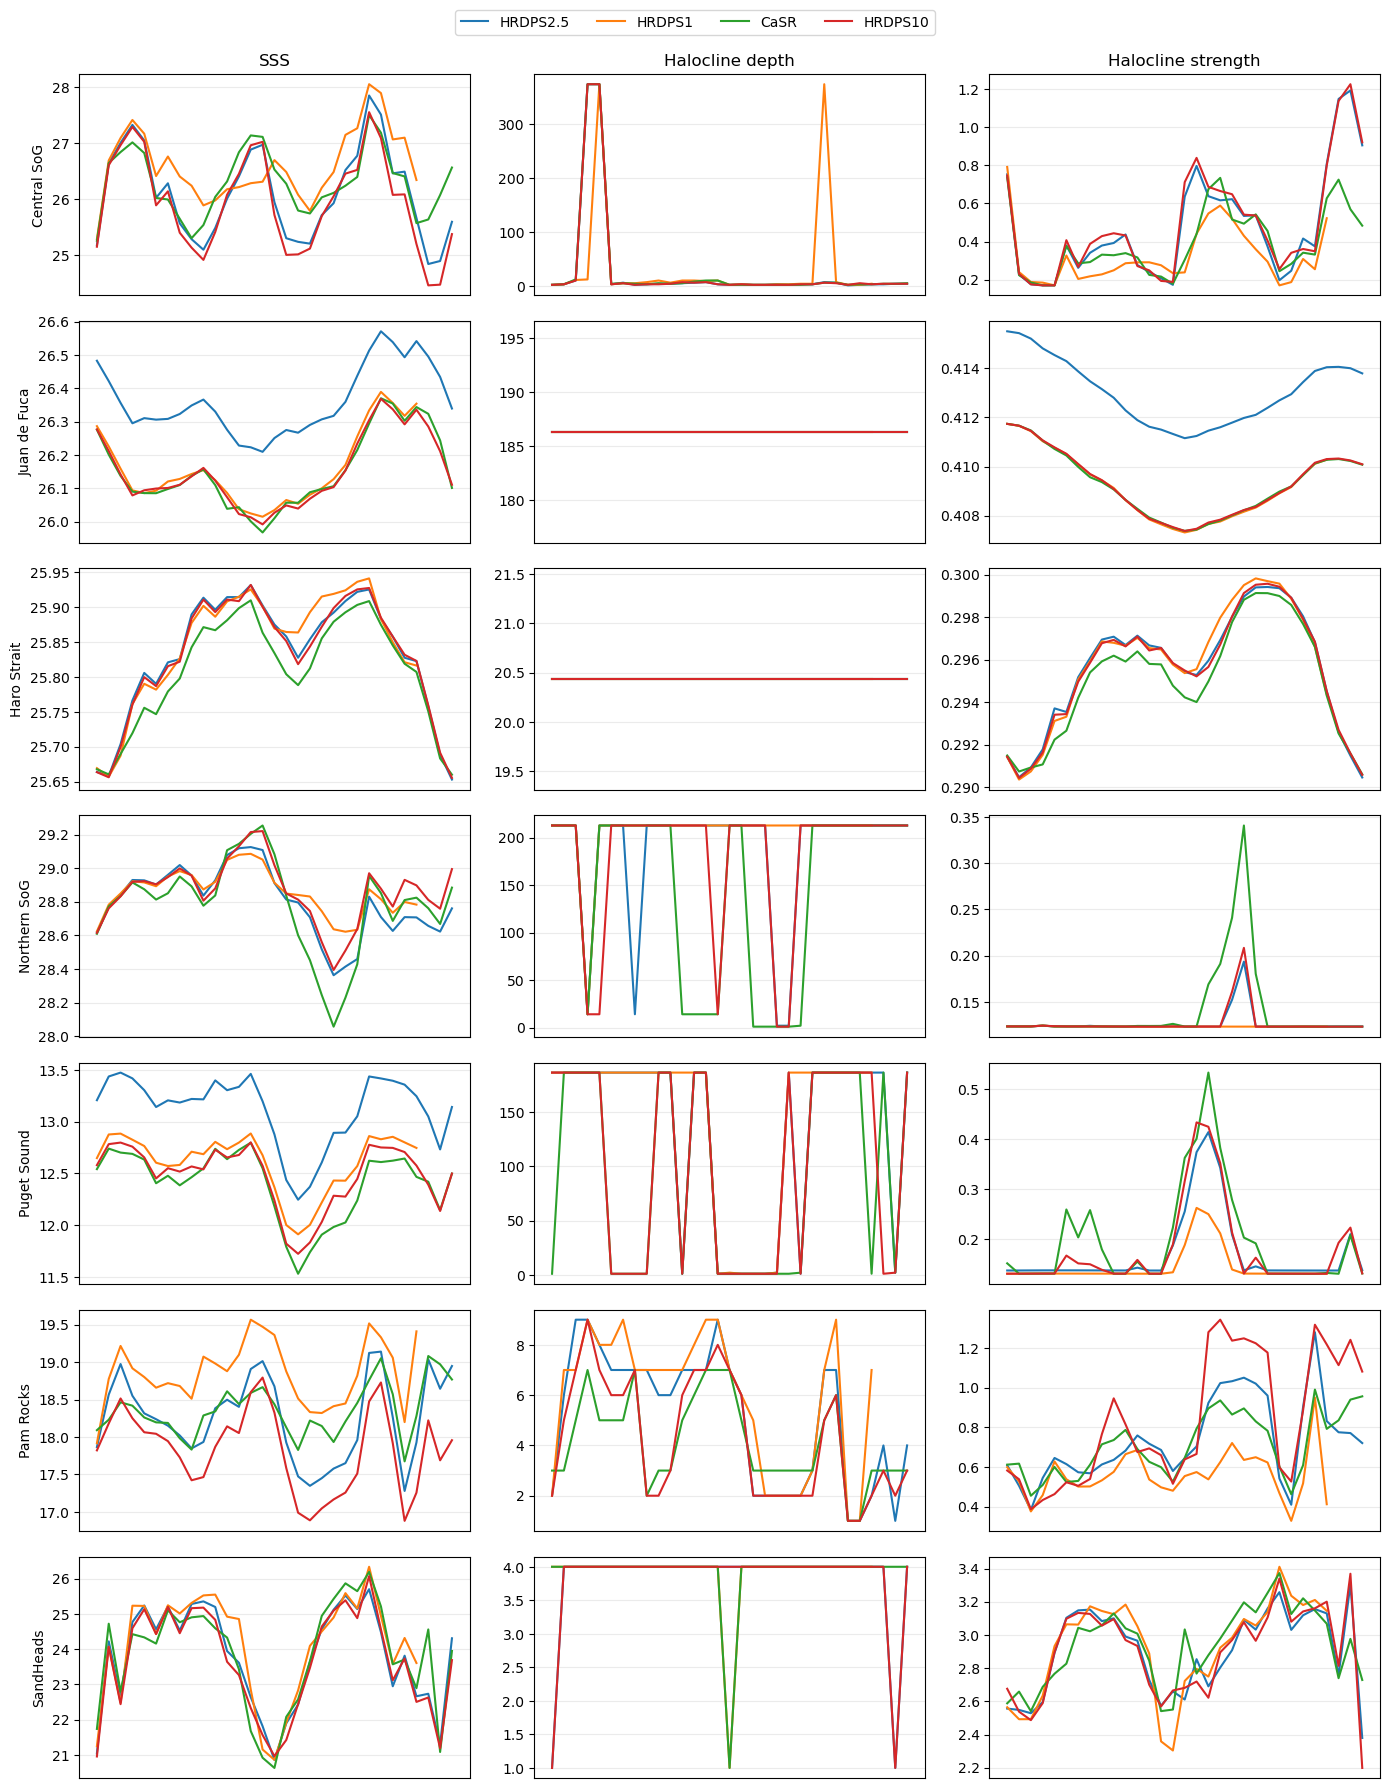

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PATH
# ============================================================

DATA_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare/physical"
)


# ============================================================
# 2. SETTINGS
# ============================================================

REGIONS = [
    "Central SoG",
    "Juan de Fuca",
    "Haro Strait",
    "Northern SoG",
    "Puget Sound",
    "Pam Rocks",
    "SandHeads",
]

MODELS = [
    "HRDPS2.5",
    "HRDPS1",
    "CaSR",
    "HRDPS10",
]

VARIABLES = [
    ("SSS", "SSS"),
    ("halocline_depth_m", "Halocline depth"),
    (
        "halocline_strength_psu_per_m",
        "Halocline strength",
    ),
]


# ============================================================
# 3. HELPERS
# ============================================================

def safe_filename(name):
    return name.replace(" ", "_")


# ============================================================
# 4. PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=len(REGIONS),
    ncols=len(VARIABLES),
    figsize=(14, 18),
)

for row, region in enumerate(REGIONS):

    filename = (
        DATA_DIR /
        f"{safe_filename(region)}_physical.csv"
    )

    print(f"Reading: {filename}")

    df = pd.read_csv(filename)

    # Just use array index as x-axis.
    x = range(len(df))

    for col, (var_name, var_title) in enumerate(VARIABLES):

        ax = axes[row, col]

        for model in MODELS:

            column_name = f"{model}__{var_name}"

            if column_name not in df.columns:
                print(
                    f"WARNING: missing column: "
                    f"{column_name}"
                )
                continue

            ax.plot(
                x,
                df[column_name],
                label=model,
                linewidth=1.5,
            )

        # Column title only on top row
        if row == 0:
            ax.set_title(var_title)

        # Region name only on left column
        if col == 0:
            ax.set_ylabel(region)

        # No time labels
        ax.set_xticks([])

        ax.grid(alpha=0.25)


# ============================================================
# 5. ONE SHARED LEGEND
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(MODELS),
    bbox_to_anchor=(0.5, 0.995),
)

plt.tight_layout(
    rect=[0, 0, 1, 0.975]
)

plt.show()

### Biological

Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Central_SoG_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Juan_de_Fuca_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Haro_Strait_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Northern_SoG_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Puget_Sound_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Pam_Rocks_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00

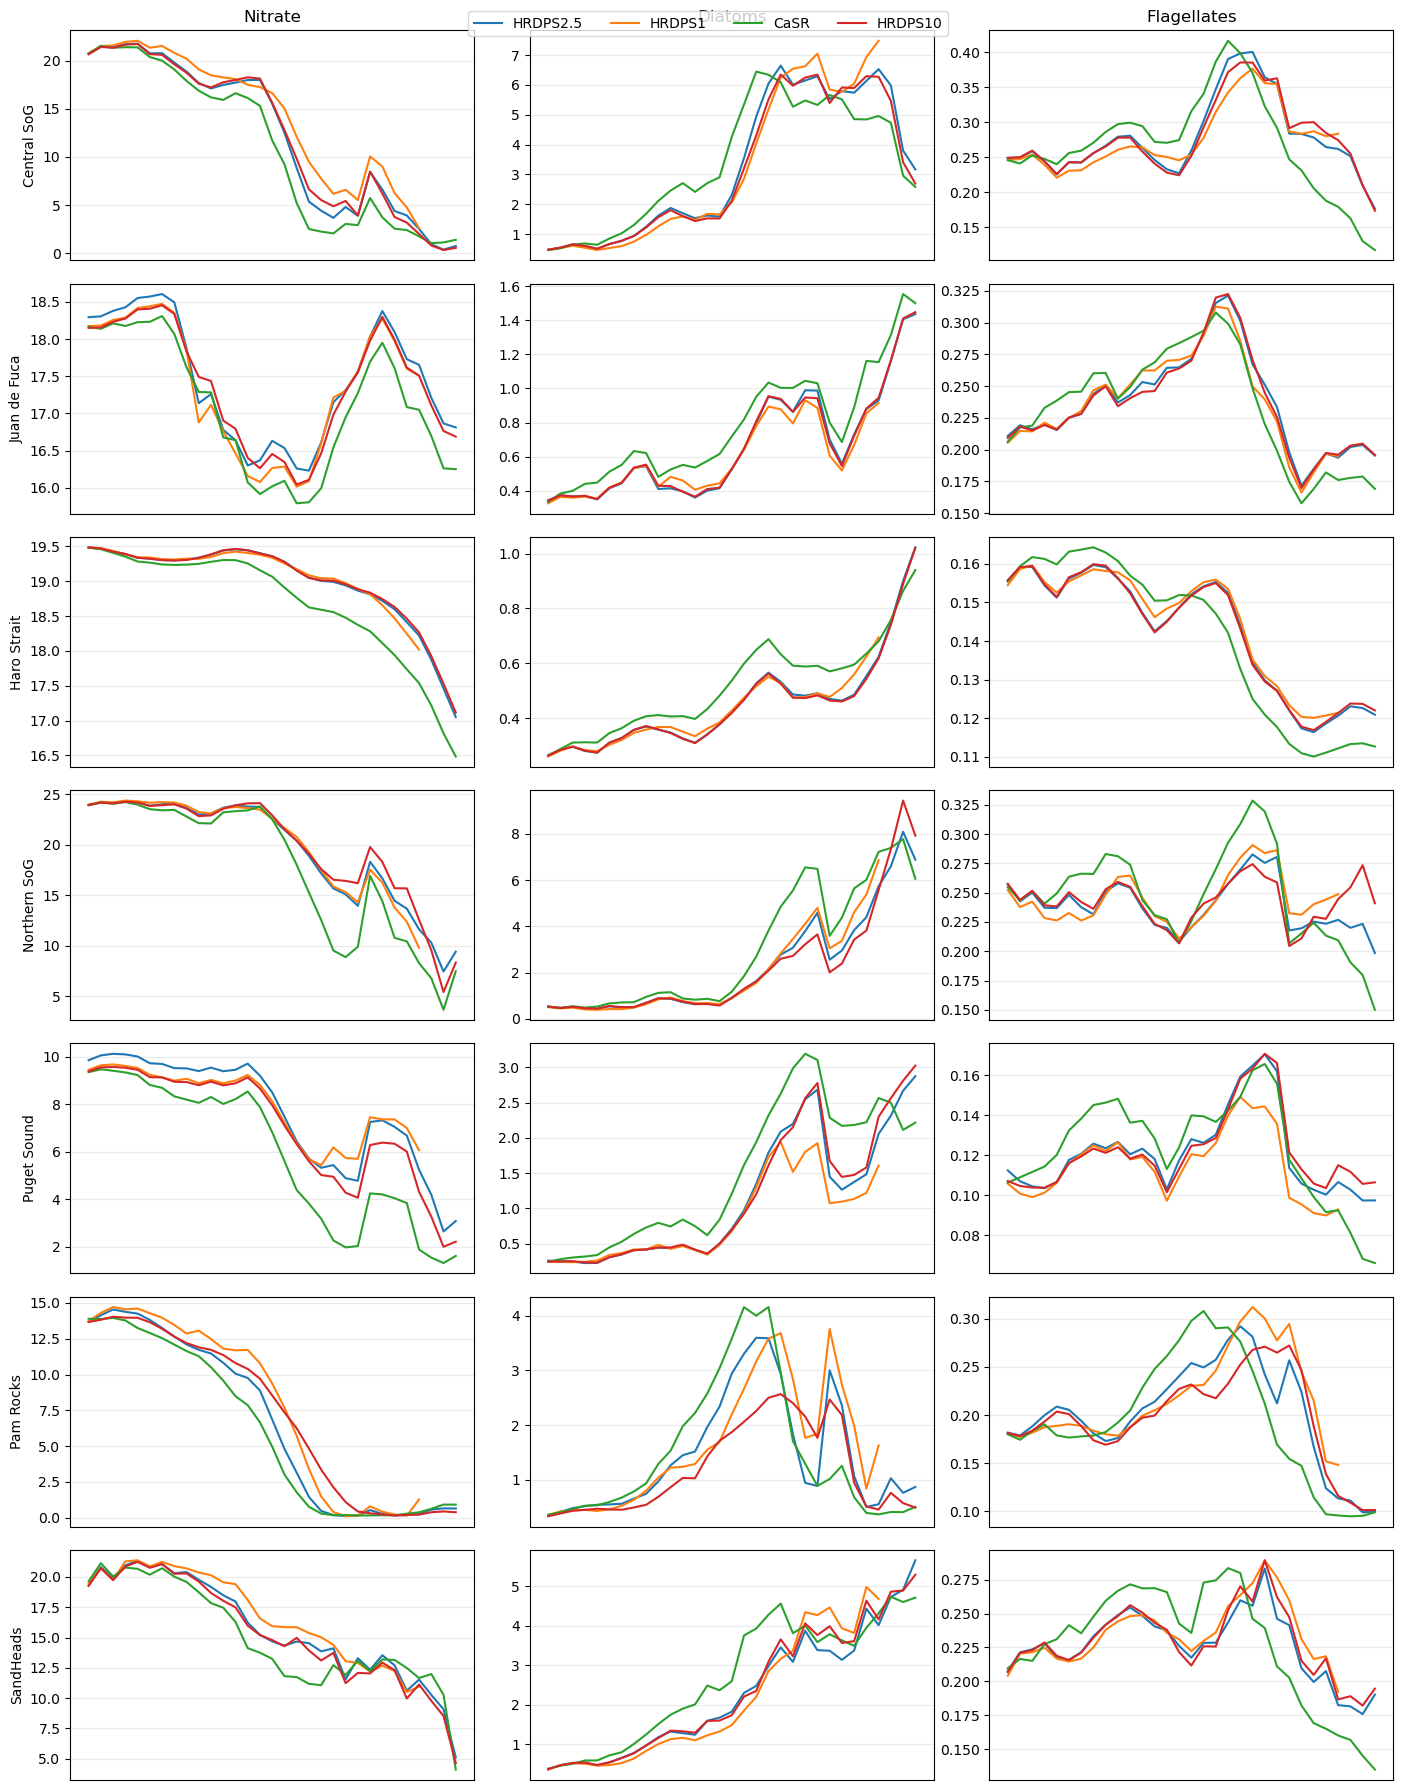

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PATH
# ============================================================

DATA_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare/biology"
)


# ============================================================
# 2. SETTINGS
# ============================================================

REGIONS = [
    "Central SoG",
    "Juan de Fuca",
    "Haro Strait",
    "Northern SoG",
    "Puget Sound",
    "Pam Rocks",
    "SandHeads",
]

MODELS = [
    "HRDPS2.5",
    "HRDPS1",
    "CaSR",
    "HRDPS10",
]

VARIABLES = [
    ("nitrate_surface", "Nitrate"),
    ("diatoms_surface", "Diatoms"),
    ("flagellates_surface", "Flagellates"),
]


# ============================================================
# 3. HELPERS
# ============================================================

def safe_filename(name):
    return name.replace(" ", "_")


# ============================================================
# 4. PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=len(REGIONS),
    ncols=len(VARIABLES),
    figsize=(14, 18),
)

for row, region in enumerate(REGIONS):

    filename = (
        DATA_DIR /
        f"{safe_filename(region)}_biology.csv"
    )

    print(f"Reading: {filename}")

    df = pd.read_csv(filename)

    # 不管时间，直接按数据点序号画
    x = range(len(df))

    for col, (var_name, var_title) in enumerate(VARIABLES):

        ax = axes[row, col]

        for model in MODELS:

            column_name = f"{model}__{var_name}"

            if column_name not in df.columns:
                print(
                    f"WARNING: missing column: "
                    f"{column_name}"
                )
                continue

            ax.plot(
                x,
                df[column_name],
                label=model,
                linewidth=1.5,
            )

        # 第一行写变量名字
        if row == 0:
            ax.set_title(var_title)

        # 第一列写地点名字
        if col == 0:
            ax.set_ylabel(region)

        # 不显示时间/日期
        ax.set_xticks([])

        ax.grid(alpha=0.25)


# ============================================================
# 5. SHARED LEGEND
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(MODELS),
    bbox_to_anchor=(0.5, 0.995),
)

plt.tight_layout()


# ============================================================
# SHOW
# ============================================================

plt.show()